---
authors:
  - name: Juniper Tyree
    orcid: 0000-0002-7923-9609
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: juntyr
  - name: Milan Klöwer
    orcid: 0000-0002-3920-4356
    affiliations:
      - name: University of Oxford
        ror: 052gg0110
    github: milankl
---

# Bit Rounding

| [![citation-badge]][citation-url] | [![pitch-badge]][pitch-url] |
|:-:|:-:|

[citation-badge]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[pitch-badge]: https://img.shields.io/badge/pitch-grey?style=for-the-badge&logo=slides&logoColor=white

[citation-url]: https://doi.org/10.1038/s43588-021-00156-2
[pitch-url]: https://github.com/climet-eu/egu26-compression-sc2-5/blob/1.0.0/pitches/a-bit-round.pdf

Bit Rounding is a filter that does not itself compress the data but reduces its precision to make it easier to compress.

Bit Rounding drops a set number of least-significant bits from the floating point mantissa, which often only contain incompressible noise / false information, by rounding in binary to a lower precision. The rounded number contains many trailing zero bits, which are highly compressible. Bit Rounding is typically followed by a lossless compressor, e.g. ZStandard or PCO.

The `BitRound` compressor is configured with `keepbits`, the number of bits in the mantissa to keep to satisfy a given relative error bound. Alternatively, if no error is known, it may be determined using Bit Information [^bitinformation].

[^bitinformation]: Klöwer, M., Razinger, M., Dominguez, J. J., Düben, P. D., & Palmer, T. N. (2021). Compressing atmospheric data into its real information content. *Nature Computational Science*, 1(11), 713–724. Available from: [doi:10.1038/s43588-021-00156-2](https://doi.org/10.1038/s43588-021-00156-2).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [3]:
data = Path("..", "data")

In [4]:
import earthkit.plots

from utils import quickplot

## Importing the `BitRound` compressor

In [5]:
from numcodecs_wasm_bit_round import BitRound

In [6]:
?BitRound

Init signature: BitRound(mode, _version='2.0.0', eb_abs=None, eb_rel=None, keepbits=None)
Docstring:     
Codec providing floating-point bit rounding.

Drops the specified number of bits from the floating point mantissa,
leaving an array that is more amenable to compression. The number of
bits to keep should be determined by information analysis of the data
to be compressed.

The approach is based on the paper by Klöwer et al. 2021
(<https://www.nature.com/articles/s43588-021-00156-2>).

Parameters
----------
mode : ...
     - "keepbits": Directly specify the number of bits of the mantissa to keep.
    
     - "abs": Pointwise absolute error.
    
     - "rel": Pointwise relative error.
_version : ..., optional, default = "2.0.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
eb_abs : ..., optional
    The pointwise absolute error bound to preserve.
    
    This error bound guarantees that
    `$|x - \hat{x}| \leq \epsilon_{abs}$`.
eb_rel : ..., opt

## Rounding a specific number of mantissa bits

Bit Rounding can be directly configured to only keep the given number of mantissa bits, `keepbits`, while rounding the others to improve the compressibility of the data:

In [7]:
keepbits = 5

BitRound(mode="keepbits", keepbits=keepbits)

BitRound(mode='keepbits', keepbits=5, _version='2.0.0')

## Bounding the pointwise absolute error

Bit Rounding can bound the absolute error using:

In [8]:
eb_abs = 0.1

BitRound(mode="abs", eb_abs=eb_abs)

BitRound(mode='abs', eb_abs=0.1, _version='2.0.0')

## Bounding the pointwise relative error

Bit Rounding can bound the relative error using:

In [9]:
eb_rel = 0.01  # 1 %

BitRound(mode="rel", eb_rel=eb_rel)

BitRound(mode='rel', eb_rel=0.01, _version='2.0.0')

## Preserving NaN Missing Values

NaN values are automatically preserved by Bit Rounding, though their exact bit patterns may change.

## Example

In [10]:
from numcodecs_combinators.stack import CodecStack
from numcodecs_wasm_zstd import Zstd

In [11]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [12]:
eb_rel = 0.01  # 1%

# stack Bit Rounding with ZStandard lossless compression
codec = CodecStack(
    BitRound(mode="rel", eb_rel=eb_rel),
    Zstd(level=3),  # default ZStandard level
)

In [13]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

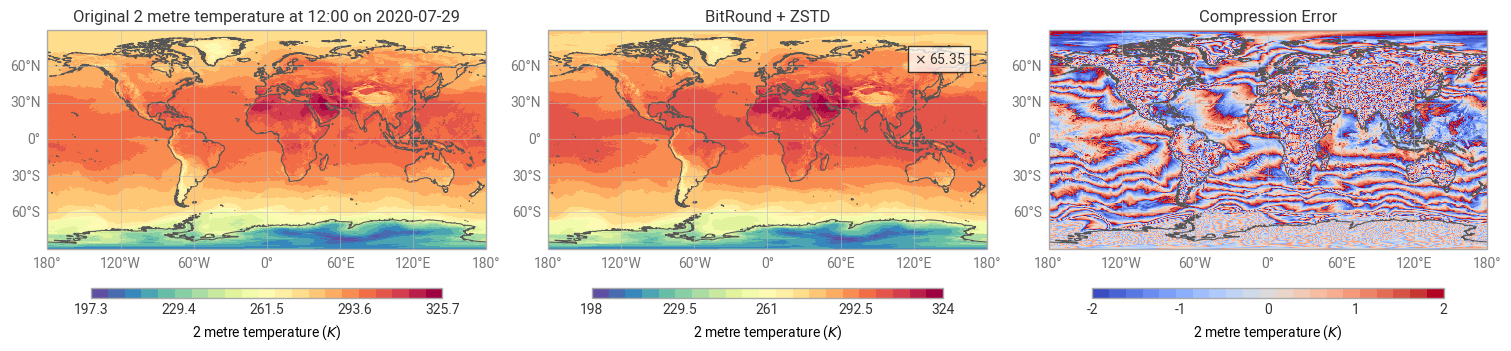

In [14]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title="BitRound + ZSTD",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()